# CUSTOMER CHURN PREDICTION


Goal : To predict whether a customer is likely to churn based on historical customer data

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
import os 
print(os.getcwd())

c:\Users\thoufik rifayi\Desktop\Projects\CustomerChurnPrediction\notebooks


In [3]:
path=r'..\data\raw\TelcoCustomerChurn.csv' #r-raw string

df=pd.read_csv(path)


In [4]:
pd.set_option('display.max_columns', None) #Displays all columns instead of truncating them with ....

In [5]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [6]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
794,4257-GAESD,Female,0,No,No,6,No,No phone service,DSL,No,No,No,No,Yes,Yes,Month-to-month,No,Credit card (automatic),45.00,298.7,No
6189,4718-WXBGI,Male,0,Yes,Yes,72,Yes,Yes,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),91.95,6614.9,No
2660,5639-NTUPK,Male,0,No,Yes,13,Yes,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Credit card (automatic),52.10,670.65,No
1473,7079-QRCBC,Female,0,No,No,24,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.75,2407.3,Yes
1849,0621-TWIEM,Male,0,No,No,10,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.55,402.6,Yes


In [7]:
df.describe(include='all') #include all columns, not just numeric ones

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [8]:
df.info() #gives a summary of the dataframe, including the number of non-null values and the data types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* Encode binary columns (Yes/No, Male/Female).
* Apply one-hot encoding to the remaining categorical columns.
* drop customer id as it is irrelevant here 
* Total charges must be numeric

In [9]:
binary_cols = [col for col in df.columns if df[col].nunique() == 2]
print(binary_cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']


In [10]:
cat_ls=[col for col in df.columns if df[col].dtype== object and col not in binary_cols]
df[cat_ls].describe()

,customerID,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod,TotalCharges
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,3,3,3,3,3,3,3,3,3,4,6531
top,7590-VHVEG,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check,20.2
freq,1,3390,3096,3498,3088,3095,3473,2810,2785,3875,2365,11


In [11]:
categorical_cols=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

Label encoding binary columns

In [12]:
df[binary_cols]=df[binary_cols].replace({'Yes':1,'No':0,'Male':1,'Female':0})
df[binary_cols].head()

C:\Users\thoufik rifayi\AppData\Local\Temp\ipykernel_2872\80597429.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols]=df[binary_cols].replace({'Yes':1,'No':0,'Male':1,'Female':0})


,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,0,1,0,0,1,0
1,1,0,0,0,1,0,0
2,1,0,0,0,1,1,1
3,1,0,0,0,0,0,0
4,0,0,0,0,1,1,1


One hot encoding Categorical columns with more than 2 categories


In [13]:
df=pd.get_dummies(df, columns=categorical_cols, drop_first=True,dtype=int) #drop_first=True to avoid dummy variable trap
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [14]:
df.dtypes

customerID                                object
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                              object
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes

removing customer id and converting total charges to int

In [15]:
df.drop(columns=['customerID'], inplace=True) #drop customerID column as it is not useful for prediction    

In [16]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce') #convert TotalCharges to numeric, coerce errors to NaN

In [17]:
correlation_matrix = df.corr(numeric_only=True) #compute the correlation matrix for numeric columns only    
churn_correlation=correlation_matrix[['Churn']].sort_values(by='Churn', ascending=False) #get the correlation of all columns with the target variable 'Churn'
print(churn_correlation)

                                          Churn
Churn                                  1.000000
InternetService_Fiber optic            0.308020
PaymentMethod_Electronic check         0.301919
MonthlyCharges                         0.193356
PaperlessBilling                       0.191825
SeniorCitizen                          0.150889
StreamingTV_Yes                        0.063228
StreamingMovies_Yes                    0.061382
MultipleLines_Yes                      0.040102
PhoneService                           0.011942
gender                                -0.008612
MultipleLines_No phone service        -0.011942
DeviceProtection_Yes                  -0.066160
OnlineBackup_Yes                      -0.082255
PaymentMethod_Mailed check            -0.091683
PaymentMethod_Credit card (automatic) -0.134302
Partner                               -0.150448
Dependents                            -0.164221
TechSupport_Yes                       -0.164674
OnlineSecurity_Yes                    -0

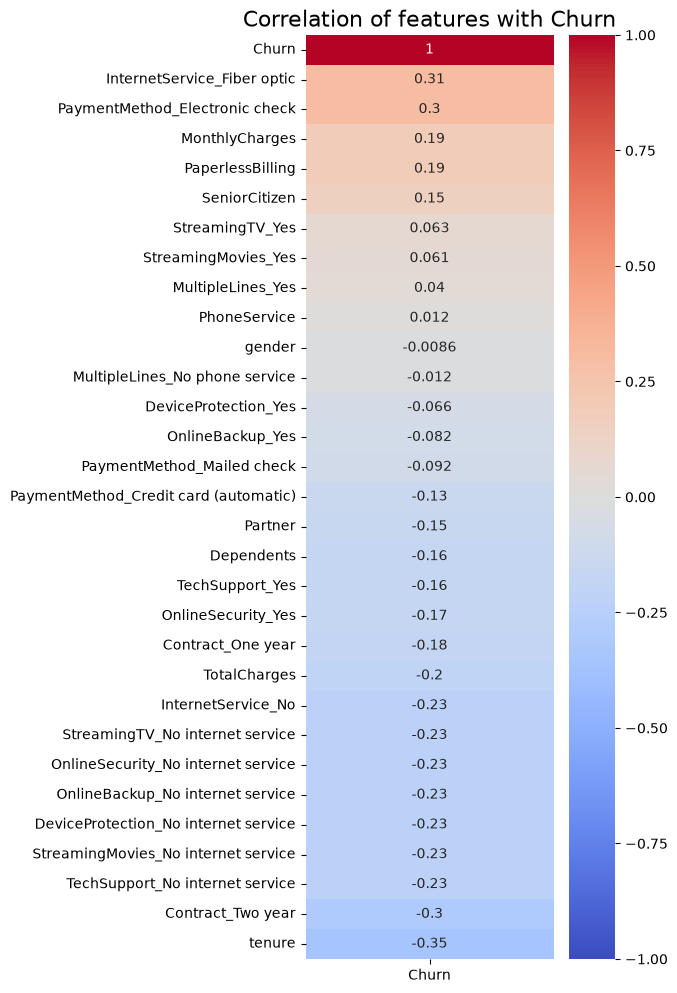

In [18]:
plt.figure(figsize=(4,12))
sns.heatmap(churn_correlation, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of features with Churn', fontsize=16)
plt.show()

Observations:

Features positively correated with churn(more likely to churn):

* Customers with fiber optic service churn more often
* Customers who paying by electronic check are more likely to churn
* Higher monthly charges are associated with more churn
* Customers using paperless billing churn more
* senior citizens have a slightly higher churn rate

Features negatively correated with churn(less likely to churn):

* Customers who stayed longer are less likely to churn (tenure(-0.35))
* Customers with 2 year contract stay longer



In [19]:
internet_corr=correlation_matrix[['InternetService_No']].sort_values(by='InternetService_No', ascending=False)
print(internet_corr) 

                                       InternetService_No
InternetService_No                               1.000000
OnlineSecurity_No internet service               1.000000
StreamingMovies_No internet service              1.000000
TechSupport_No internet service                  1.000000
StreamingTV_No internet service                  1.000000
DeviceProtection_No internet service             1.000000
OnlineBackup_No internet service                 1.000000
PaymentMethod_Mailed check                       0.321361
Contract_Two year                                0.218278
PhoneService                                     0.172209
Dependents                                       0.139812
Contract_One year                                0.038004
gender                                           0.006026
PaymentMethod_Credit card (automatic)            0.001030
Partner                                          0.000615
tenure                                          -0.039062
MultipleLines_

#### Reduce Multicolinearity caused  by redundant dummy variables

InternetService_No, StreamingTV_No internet service, OnlineSecurity_No internet service etc

These are one-hot encoded categorical variables. They are expected to have similar correlations because they all describe the same underlying condition (customers without internet service). 
Suppose a customer has no internet service. Then all these columns become 1 simultaneously. These columns contain essentially the same information.If any of these columns is 1, then No_internet_service becomes 1. Otherwise it becomes 0.So instead of six identical indicators, you keep just one. 


In [20]:
### Remove the redundant dummy columns
no_internet_cols=[col for col in df.columns if 'No internet service' in col]
df.drop(columns=no_internet_cols, inplace=True)

In [21]:
df[['PhoneService','MultipleLines_No phone service']].head(10)

,PhoneService,MultipleLines_No phone service
0,0,1
1,1,0
2,1,0
3,0,1
4,1,0
5,1,0
6,1,0
7,0,1
8,1,0
9,1,0


we can see that:

MultipleLines_No phone service=1−PhoneService

This means the two variables are perfect complements. One can be calculated exactly from the other, so they carry the same information.

In [22]:
correlation_matrix2=df.corr(numeric_only=True) #compute the correlation matrix for numeric columns only
PS_correlation=correlation_matrix2[['PhoneService']].sort_values(by='PhoneService', ascending=False) 
print(PS_correlation)

                                       PhoneService
PhoneService                               1.000000
InternetService_Fiber optic                0.289999
MultipleLines_Yes                          0.279690
MonthlyCharges                             0.247398
InternetService_No                         0.172209
TotalCharges                               0.113008
Partner                                    0.017706
PaperlessBilling                           0.016505
Churn                                      0.011942
SeniorCitizen                              0.008576
tenure                                     0.008448
Contract_Two year                          0.003519
PaymentMethod_Electronic check             0.003062
Dependents                                -0.001762
Contract_One year                         -0.002791
PaymentMethod_Mailed check                -0.003319
gender                                    -0.006488
PaymentMethod_Credit card (automatic)     -0.007721
StreamingTV_

Perfect negative correlation.A customer without phone service cannot have multiple lines. Keeping both variables will produce perfect multicollinearity, leading to an infinite (or extremely large) VIF. So Keep only one of them.

In [23]:
df.drop(columns=['MultipleLines_No phone service'], inplace=True)

Prepare feature matrix(X)

In [24]:
X=df.drop(columns=['Churn'])

Calculate VIF

For each predictor, VIF asks: "How well can this predictor be explained by all the other predictors?"
* If a predictor can barely be predicted by the others, its VIF is close to 1.
* If it can almost be perfectly predicted by the others, its VIF becomes very large.

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

#VIF calculation cannot handle missing (NaN) or infinite (inf, -inf) values.
X = X.replace([np.inf, -np.inf], np.nan)
X.isna().sum() #check for missing values
X.dropna(inplace=True) #drop rows with missing values


In [26]:
vif_data= pd.DataFrame()
vif_data['feature']=X.columns
vif_data['VIF']=[variance_inflation_factor(X.values, i) for i in  range(X.shape[1])]
vif_data.sort_values(by='VIF', ascending=False, inplace=True)
print(vif_data)

                                  feature         VIF
7                          MonthlyCharges  212.353073
5                            PhoneService   47.244378
8                            TotalCharges   21.374002
4                                  tenure   20.482153
10            InternetService_Fiber optic   17.695260
11                     InternetService_No    8.234451
17                    StreamingMovies_Yes    5.090603
16                        StreamingTV_Yes    4.928957
19                      Contract_Two year    3.487502
14                   DeviceProtection_Yes    2.992570
6                        PaperlessBilling    2.956951
21         PaymentMethod_Electronic check    2.955994
13                       OnlineBackup_Yes    2.909898
9                       MultipleLines_Yes    2.861614
2                                 Partner    2.824725
15                        TechSupport_Yes    2.758343
12                     OnlineSecurity_Yes    2.682712
22             PaymentMethod

The VIF analysis indicates the presence of multicollinearity among a few predictor variables. MonthlyCharges (VIF = 212.35), PhoneService (47.24), TotalCharges (21.37), tenure (20.48), and InternetService_Fiber optic (17.70) have very high VIF values, suggesting strong correlations with other predictors.

This can be addressed by removing highly correlated features (e.g., TotalCharges) or by using regularization techniques such as Ridge or Lasso regression, which reduce the impact of multicollinearity. Alternatively, tree-based models (e.g., Decision Trees, Random Forest, XGBoost) are generally less sensitive to multicollinearity because they select splits based on the feature that best reduces impurity. Highly correlated features may compete with one another, but they do not typically lead to unstable predictions as they do in linear models.

In [27]:
df['Churn'].value_counts() #check the distribution of the target variable 'Churn'

Churn
0    5174
1    1869
Name: count, dtype: int64

The target variable is imbalanced, with 5,174 non-churn customers (0) and 1,869 churn customers (1). In churn prediction, recall is often the most important evaluation metric because the cost of missing a customer who is likely to churn (false negative) is typically much higher than incorrectly identifying a loyal customer as a potential churner (false positive). A false negative results in losing the opportunity to intervene and retain the customer, whereas a false positive may only incur the cost of an unnecessary retention effort.

The choice of evaluation metric depends on the business objective:

Prioritize Recall when retention campaigns are relatively inexpensive and the goal is to identify as many churners as possible.
Use the F1-score when both precision and recall are important, providing a balance between minimizing false positives and false negatives.
Use ROC-AUC or PR-AUC when the objective is to rank customers by their likelihood of churning rather than making a fixed classification decision.

Overall, for customer churn prediction, recall and F1-score are generally more informative than accuracy, especially when the classes are imbalanced.

### MACHINE LEARNING

In [28]:
from sklearn.model_selection import train_test_split

X=df.drop(columns=['Churn'])
y=df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y) #stratify=y to maintain the same distribution of the target variable in both train and test sets

Most classifiers predict a probability of churn. By default:

If probability ≥ 0.5 → Predict Churn (1)
If probability < 0.5 → Predict No Churn (0)

By lowering the threshold to 0.3: More customers are predicted as churners. Recall increases (you catch more actual churners). Precision may decrease (more false positives).

This is useful in churn prediction because missing a customer who is actually going to leave (a false negative) is often more costly than contacting a customer who wasn't going to leave (a false positive).

In [29]:
THRESHOLD = 0.3 

### RANDOM FOREST

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1) 

#n_estimators=300 - Builds 300 decision trees.More trees generally improve stability but increase training time.
#class_weight='balanced' - Automatically assigns higher weight to the minority class.Useful when your dataset is imbalanced.
#random_state=42 - Makes the results reproducible.
#n_jobs=-1 - Uses all available CPU cores for faster training.

rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [31]:
prob = rf_model.predict_proba(X_test)[:, 1]
#predict the probability of the positive class (Churn=1) for the test set
#[:, 1] selects the probability of the positive class (class = 1).
print(prob)

[0.00333333 0.87       0.08666667 ... 0.12333333 0.16666667 0.02333333]


In [32]:
y_pred = (prob >= THRESHOLD).astype(int) #convert probabilities to binary predictions based on the threshold
#.astype(int) Convert True and False to integers 0 and 1 respectively
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

Print the classification report to evaluate the model's performance

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.66      0.77      1035
           1       0.48      0.86      0.61       374

    accuracy                           0.71      1409
   macro avg       0.70      0.76      0.69      1409
weighted avg       0.81      0.71      0.73      1409



Comparing metrics across thresholds helps identify the threshold that provides the best trade-off between precision and recall for the problem.

In [34]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("Threshold tuning for Random Forest")

print(f"{'Threshold':<10}{'Precision_1':<15}{'Recall_1':<10}{'F1_Score_1':<10}") 

for threshold in np.arange(0.25, 0.55, 0.05):
    y_pred = (prob >= threshold).astype(int)
    Precision_1 = precision_score(y_test,y_pred)
    Recall_1 = recall_score(y_test,y_pred)
    F1_Score_1 = f1_score(y_test,y_pred)
    print(f"{threshold:<10.2f}{Precision_1:<15.3f}{Recall_1:<10.3f}{F1_Score_1:<10.3f}")



Threshold tuning for Random Forest
Threshold Precision_1    Recall_1  F1_Score_1
0.25      0.451          0.890     0.598     
0.30      0.479          0.856     0.614     
0.35      0.496          0.813     0.616     
0.40      0.511          0.762     0.612     
0.45      0.535          0.701     0.606     
0.50      0.552          0.650     0.597     
0.55      0.570          0.586     0.578     


The random forest model achieved an overall accuracy 71%. The model attained a recall of 86% and a precision of 48% at the initial threshold(0.3), indicating that it successfully identified most customers who actually churned but also generated a considerable amount of false positives. Threshold tuning showed that the highest F1-Score (0.616) was obtained at a threshold of 0.35,with a precision of 49.6% and recall of 81.3%. Since customer churn prediction prioritises identifying customers at risk of leaving, a threshold of 0.35 provides a good balance between detecting churners and minimizing unnecessary retention efforts. 

If the business places greater emphasis on capturing nearly all potential churners, a threshold of 0.30 may also be considered because it achieves a higher recall of 85.6% with only a slight reduction in F1 score.

### Light Gradient Boosting Machine (LightGBM)

In [35]:
from lightgbm import LGBMClassifier #LGBMClassifier is the classification algorithm used for predicting categories.
import time #Python's built-in time module. It measures: Model training time and Prediction time. This helps compare algorithms.

In [36]:
## Create the LightGBM Model
lgbm_model = LGBMClassifier(n_estimators=500, learning_rate=0.05, class_weight='balanced', random_state=42, n_jobs=-1)

#n_estimators=500 - Builds 500 decision trees. Each tree corrects mistakes made by previous trees. 
# More trees generally improve stability but increase training time.
#learning_rate=0.05 - Controls how much each tree contributes.Think of learning like studying. 
# Large learning rate: Study quickly. Small learning rate:Study slowly
# A lower learning rate means the model learns more slowly, which can lead to better performance but requires more trees (n_estimators) to achieve the same level of accuracy.
#class_weight='balanced' - Automatically assigns higher weight to the minority class.Useful when your dataset is imbalanced.
#random_state=42 - Makes the results reproducible.
#n_jobs=-1 - Uses all available CPU cores for faster training.

## Start Training Timer
start_time = time.time() #Record the current time before training the model. This will be used to calculate how long the training takes.

#Train the LightGBM model on the training data
lgbm_model.fit(X_train, y_train)
#The model learns patterns from the training data. During training, LightGBM builds 500 trees. 
# Each tree reduces previous errors. Finally,the model stores learned patterns.

#Calculate Training Time
end_time=time.time() #Record the current time after training the model. 
training_time=end_time-start_time
print(f"LightGBM Training Time: {training_time:.2f} seconds")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003096 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM Training Time: 0.88 seconds


In [37]:
#start prediction timer
start_time=time.time()

#predict the probability of the positive class (Churn=1) for the test set
y_pred_prob = lgbm_model.predict_proba(X_test)[:, 1] #takes every row and second column (probability of Churn=1) from the predicted probabilities.

#Convert Probability into Class
y_pred = (y_pred_prob >= THRESHOLD).astype(int) #convert probabilities to binary predictions based on the threshold

#Calculate Prediction Time
end_time=time.time()
prediction_time=end_time-start_time
print(f"LightGBM Prediction Time: {prediction_time: .2f} seconds")


LightGBM Prediction Time:  0.05 seconds


In [38]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1035
           1       0.50      0.82      0.62       374

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.73      0.75      1409



In [39]:
#Threshold tuning for LightGBM
print("Threshold tuning for LightGBM")

print(f"{'Threshold':<10} {'Precision_1':<15} {'Recall_1':<10} {'F1_Score_1':<10}")
for threshold in np.arange(0.25,0.55,0.05):
    y_pred = (y_pred_prob >= threshold).astype(int)
    Precision_1 = precision_score(y_test,y_pred)
    Recall_1 = recall_score(y_test,y_pred)
    F1_Score_1 = f1_score(y_test,y_pred)
    print(f"{threshold:<10.2f} {Precision_1:<15.2f} {Recall_1:<10.2f} {F1_Score_1:<10.2f}")

Threshold tuning for LightGBM
Threshold  Precision_1     Recall_1   F1_Score_1
0.25       0.48            0.84       0.61      
0.30       0.50            0.82       0.62      
0.35       0.51            0.79       0.62      
0.40       0.52            0.76       0.62      
0.45       0.54            0.74       0.62      
0.50       0.55            0.70       0.62      
0.55       0.57            0.67       0.61      


Observations:
* As the threshold increases:
 * Precision increases from 0.48 to 0.57, meaning fewer false positives.
 * Recall decreases from 0.84 to 0.67, meaning more actual churners are missed.
 * F1-score remains around 0.62 for thresholds between 0.30 and 0.50, indicating that the model is relatively stable across this range. Because the F1-score is essentially the same across 0.30–0.50, the threshold should be selected based on business costs rather than model performance alone.


The LightGBM model performs very similarly to the Random Forest model in terms of F1-score but offers a wider range of thresholds with nearly identical F1 performance. This makes LightGBM more flexible for adapting to different business priorities. For customer churn prediction, 0.30 is often the preferred threshold because it maintains a high recall (82%) while achieving the maximum F1-score, ensuring that most customers at risk of churning are identified for retention efforts.

### Extreme Gradient Boosting (XGBoost)

In [40]:
from xgboost import XGBClassifier #XGBClassifier class from the xgboost library is used to create an XGBoost model for classification problems.

#Calculate Class Imbalance

#Calculates the ratio of negative to positive samples in the training set. This helps XGBoost handle class imbalance.
#Without scale_pos_weight, XGBoost tries to minimize the total number of mistakes. And it may simply predict the majority class for most samples and still achieve high accuracy.
#As a result, the model pays more attention(weight) to the minority class and is more likely to detect any  rare event.
scale_pos_weight = (y_train == 0).sum() / (y_train ==1).sum() 

xgb_model =XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, 
                         scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1, eval_metric='logloss')


# max_depth=6- Maximum depth of each decision tree. Deeper trees learn more complex patterns but can overfit. A depth of 6 is a common compromise.
# subsample=0.8 Uses only 80% of the training samples to build each tree. Adds randomness and reduces overfitting.
# colsample_bytree=0.8. Uses only 80% of the features (columns) for each tree. Makes trees more diverse and reduces overfitting.
# scale_pos_weight=scale_pos_weight Gives extra weight to the minority (positive) class.,Useful for imbalanced datasets.
# eval_metric='logloss' Uses Log Loss to evaluate the model during training.Measures how well the predicted probabilities match the true labels. Lower log loss is better.


# Training timer
start_train = time.time()
xgb_model.fit(X_train, y_train)
train_time = time.time() - start_train
print(f"xgboostTraining time: {train_time:.2f} seconds")



xgboostTraining time: 1.24 seconds


In [41]:

#start prediction timer
start_time=time.time()
y_pred_prob = xgb_model.predict_proba(X_test)[:, 1] 
y_pred = (y_pred_prob >= THRESHOLD).astype(int) 
end_time=time.time()
prediction_time=end_time-start_time
print(f"XGBoost Prediction Time: {prediction_time: .2f} seconds")

XGBoost Prediction Time:  0.06 seconds


In [42]:

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.911     0.678     0.777      1035
           1      0.478     0.816     0.603       374

    accuracy                          0.715      1409
   macro avg      0.694     0.747     0.690      1409
weighted avg      0.796     0.715     0.731      1409



The overall accuracy is 71.5%, but because the dataset is imbalanced, the recall and F1-score for the churn class provide a more meaningful assessment of model performance.

In [43]:
#Threshold tuning for XGBoost
print("Threshold tuning for XGBoost")

print(f"{'Threshold':<10} {'Precision_1':<15} {'Recall_1':<10} {'F1_Score_1':<10}")
for threshold in np.arange(0.25,0.55,0.05):
    y_pred = (y_pred_prob >= threshold).astype(int)
    Precision_1 = precision_score(y_test,y_pred)
    Recall_1 = recall_score(y_test,y_pred)
    F1_Score_1 = f1_score(y_test,y_pred)
    print(f"{threshold:<10.2f} {Precision_1:<15.2f} {Recall_1:<10.2f} {F1_Score_1:<10.2f}")

Threshold tuning for XGBoost
Threshold  Precision_1     Recall_1   F1_Score_1
0.25       0.46            0.83       0.59      
0.30       0.48            0.82       0.60      
0.35       0.50            0.79       0.61      
0.40       0.52            0.76       0.62      
0.45       0.53            0.74       0.62      
0.50       0.56            0.71       0.62      
0.55       0.57            0.66       0.61      


Observations:

As the decision threshold increases:

* Precsion increases from 0.46 to 0.57, reducing false positives
* Recall decreases from 0.83 to 0.66, meaning more actual churners are missed.
* F1-score peaks at approximately 0.62 for thresholds between 0.40 and 0.50, indicating a good balance between precision and recall.Here threshold of 0.40 maintains a higher recall (0.76) while improving precision (0.52). In customer churn prediction, identifying customers who are likely to churn is generally more important than minimizing false positives, as missing a potential churner may result in customer loss and revenue reduction. Therefore, the threshold of 0.40 provides an effective balance between customer retention and campaign efficiency.

### COMPARISON OF MODELS:

Among the three machine learning models evaluated, LightGBM demonstrated the best overall performance for customer churn prediction. It achieved the highest F1-score (0.62, tied with XGBoost), the highest recall (0.82), and the fastest training time (1.03 seconds). Although XGBoost produced slightly higher precision (up to 0.56) and a faster prediction time (0.06 seconds), LightGBM is better suited for churn prediction because its higher recall enables it to identify more customers at risk of churning. Since retaining potential churners is typically the primary objective of churn prediction systems, LightGBM was selected as the final model due to its superior balance between predictive performance and computational efficiency.

### Hyperparameter Tuning (Optuna) & Experiment Tracking (MLFlow)

In [44]:
#import library
import optuna 

#Define the Objective Function
def objective(trial):
    #Every time Optuna runs one experiment, it calls this function.
    #One execution = One Trial.

    #Define Hyperparameters - Creates a dictionary that stores all hyperparameters.
    params={
        "n_estimators": trial.suggest_int("n_estimators", 300, 800), #Optuna chooses an integer between 300 and 800. More trees usually improve performance but increase training time.
        "learning_rate": trial.suggest_float("learning_rate", 0.01,0.2),
        "max_depth" : trial.suggest_int("max_depth", 3,10),
        "num_leaves" : trial.suggest_int("num_leaves", 20,150), #This is one of the most important LightGBM parameters.controls how many leaf nodes each tree can have.Higher values can increase accuracy but may overfit.
        "min_child_samples" : trial.suggest_int("min_child_samples", 10,100), #Controls the minimum number of samples required in one leaf.
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0), #Feature Fraction-Only a percentage of features are used to build each tree.Helps reduce overfitting.
        "subsample": trial.suggest_float("subsample", 0.5, 1.0), #Bagging Fraction - Uses only a fraction of the training data for each tree. Improves generalization.
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5), #Adds L1 regularization. Higher value -> simpler model ->less overfitting
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5), #Adds L2 regularization. Helps prevent overly complex trees.
        "class_weight": {0:1, 1:(y_train==0).sum()/(y_train==1).sum()}, 
        #Assigns a weight of 1 to class 0 (usually the majority class).Counts the number of samples belonging to class 0. 
        #Counts the number of samples belonging to class 1. Assigns a higher weight to class 1
        #Weight for class 1= Number of class 1 samples/Number of class 0 samples​
        "random_state": 42,
        "n_jobs": -1

    }

    #Create the Model
    model = LGBMClassifier(**params) #Creates a LightGBM model using the selected hyperparameters.
    #The **params syntax unpacks the dictionary into keyword arguments.

    #Train the Model
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    THRESHOLD = 0.30
    y_pred = (prob >= THRESHOLD).astype(int)  # Keep your tuned threshold
    return recall_score(y_test, y_pred, pos_label=1)  # pos_label=1 → Calculate recall for class 1.

#Since Optuna is maximizing recall, it tries to find the hyperparameters that produce the highest recall.

#Create an Optuna study
study = optuna.create_study(direction="maximize")
#creates an Optuna study, which manages the hyperparameter optimization process.
#direction="maximize" tells Optuna to maximize the objective function (e.g., recall, accuracy, F1-score, or AUC).
#here the objective function returns recall value and the direction is "maximize", Optuna selects the trial with the highest recall.
#During optimization, Optuna tests different hyperparameter combinations and keeps the one with the highest objective value.


#Run Hyperparameter Optimization
study.optimize(objective, n_trials=30)  #Optuna performs 30 trials. Each trial uses a different combination of hyperparameters.

#Display the Best Results
print("Best Parameters:", study.best_params)

print("Best Recall:", study.best_value)

c:\Users\thoufik rifayi\Desktop\Projects\CustomerChurnPrediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-23 14:27:44,541] A new study created in memory with name: no-name-70a2c3cf-fc73-4d61-9257-044993d7626a


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000554 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-07-23 14:27:45,045] Trial 0 finished with value: 0.8502673796791443 and parameters: {'n_estimators': 485, 'learning_rate': 0.141728376651409, 'max_depth': 10, 'num_leaves': 41, 'min_child_samples': 15, 'colsample_bytree': 0.539965744168633, 'subsample': 0.7703913972488032, 'reg_alpha': 4.579361596031697, 'reg_lambda': 1.8335989284679095}. Best is trial 0 with value: 0.8502673796791443.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[I 2026-07-23 14:27:45,696] Trial 1 finished with value: 0.8556149732620321 and parameters: {'n_estimators': 733, 'learning_rate': 0.08548827371211323, 'max_depth': 8, 'num_leaves': 122, 'min_child_samples': 64, 'colsample_bytree': 0.8677458273194043, 'subsample': 0.8280551058072676, 'reg_alpha': 4.565582464779289, 'reg_lambda': 4.1501490273610635}. Best is trial 1 with value: 0.8556149732620321.


...

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000700 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 623
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

[I 2026-07-23 14:28:02,305] Trial 28 finished with value: 0.9010695187165776 and parameters: {'n_estimators': 411, 'learning_rate': 0.025913873187883088, 'max_depth': 4, 'num_leaves': 114, 'min_child_samples': 68, 'colsample_bytree': 0.897070978504604, 'subsample': 0.5390574905277423, 'reg_alpha': 0.01736022354846447, 'reg_lambda': 1.1975789107730472}. Best is trial 21 with value: 0.9144385026737968.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-07-23 14:28:03,023] Trial 29 finished with value: 0.8475935828877005 and parameters: {'n_estimators': 455, 'learning_rate': 0.04878445209967905, 'max_depth': 6, 'num_leaves': 139, 'min_child_samples': 48, 'colsample_bytree': 0.9586794852989222, 'subsample': 0.6521424834302496, 'reg_alpha': 0.8520061457161893, 'reg_lambda': 1.7057423566412606}. Best is trial 21 with value: 0.9144385026737968.


Best Parameters: {'n_estimators': 301, 'learning_rate': 0.05918746181225819, 'max_depth': 3, 'num_leaves': 149, 'min_child_samples': 100, 'colsample_bytree': 0.9848444176247063, 'subsample': 0.5008125036130902, 'reg_alpha': 0.346416098974257, 'reg_lambda': 0.7903243020495482}
Best Recall: 0.9144385026737968


## Build the final model 

Add the Fixed Parameters.Optuna only tunes the parameters you specified. You still need to add the fixed parameters used during training.

In [45]:
best_params = study.best_params.copy()
best_params.update({
    "class_weight": {
        0: 1,
        1: (y_train == 0).sum() / (y_train == 1).sum()
    },
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1 #Suppress almost all messages and warnings.This keeps your output cleaner.
})

In [46]:
final_model = LGBMClassifier(**best_params)

# Start timer
start_train = time.time()
# Train the model
final_model.fit(X_train, y_train)
# End timer
train_time = time.time() - start_train

print(f"Training Time: {train_time:.2f} seconds")


Training Time: 0.30 seconds


In [47]:

# Make Predictions

# Start timer
start_pred = time.time()

# Predict probabilities
proba = final_model.predict_proba(X_test)[:, 1]

# Apply the optimized threshold
THRESHOLD=0.30
y_pred = (proba >= THRESHOLD).astype(int)

# End timer
pred_time = time.time() - start_pred

print(f"Prediction Time: {pred_time:.4f} seconds")


# Classification Report
print(classification_report(y_test, y_pred, digits=3))

Prediction Time: 0.0203 seconds
              precision    recall  f1-score   support

           0      0.950     0.586     0.724      1035
           1      0.444     0.914     0.597       374

    accuracy                          0.673      1409
   macro avg      0.697     0.750     0.661      1409
weighted avg      0.815     0.673     0.691      1409



### Performance Analysis

* The objective of this customer churn prediction model was to maximize recall for churn customers (Class 1). This approach is appropriate because failing to identify a customer who is likely to churn (a false negative) can result in lost revenue and missed retention opportunities.
* The model achieved a recall of 91.2% for churn customers, indicating that it successfully identified the vast majority of customers who were actually at risk of leaving. This means the model is highly effective as an early warning system, enabling the business to target most potential churners with retention strategies.
* The precision for churn prediction is 43.8%, which indicates that not every customer predicted to churn will actually leave. In other words, the model produces a relatively high number of false positives. This behavior is expected because the classification threshold was intentionally lowered to 0.30 to prioritize identifying as many churning customers as possible. While this may increase the number of customers unnecessarily included in retention campaigns, it substantially reduces the likelihood of missing customers who are genuinely at risk of churning.
* For non-churn customers (Class 0), the model achieved a precision of 94.8%, indicating that customers predicted to remain with the company are highly likely to stay. However, the recall for this class is 57.7%, meaning that many non-churning customers were classified as potential churners. This trade-off reflects the model's focus on maximizing churn detection rather than optimizing overall accuracy.
* The overall accuracy of 66.6% should not be interpreted as the primary measure of performance because the dataset is imbalanced, with substantially more non-churn customers (1,035) than churn customers (374). For customer churn prediction, recall and F1-score provide more meaningful performance measures than accuracy.

### LightGBM with MLflow

In [48]:
import mlflow #import MLflow library used to track machine learning experiments. It records parameters, ,etrics, trained models and artifacts.
import mlflow.lightgbm #imports the lightGBM integration for MLflow. It enables saving and loading LGBMClassifier models.
import os #import python's os module for working with directories and file paths
import time #import time module to measure how long training and prediction take
from lightgbm import LGBMClassifier
from sklearn.metrics import (classification_report,precision_score,recall_score,f1_score,roc_auc_score)
#roc_auc_score: Measures the model's ability to distinguish between churn and non-churn.

In [51]:
from pathlib import Path

# ----------------------------------------------------
# Set MLflow Tracking URI
# ----------------------------------------------------
project_root = os.path.abspath(os.path.join(os.getcwd(),"..")) #Go one folder up and returns the complete absolute path.
mlruns_path = Path(project_root) / "mlruns" ##The / operator in pathlib joins paths. 
mlruns_path.mkdir(parents=True, exist_ok=True) 
#This creates the mlruns folder if it doesn't already exist.creates all missing parent folders automatically. if the directory already exists, ignores it and continues.
mlflow.set_tracking_uri(mlruns_path.as_uri())  # This tells MLflow where to save experiments and as_uri() converts the path object into a proper file URI.
mlflow.set_experiment("Telco Churn - LightGBM") #This creates or selects an MLflow experiment named: "Telco Churn - LightGBM". inside this experiment, every execution becomes one Run.

# ----------------------------------------------------
# Start MLflow Run
# ----------------------------------------------------

with mlflow.start_run(run_name="Final_LightGBM"): 
    #Starts recording everything.Anything inside this block is automatically tracked. For example: parameters, metrics, model, artifacts

    #get best params from optuna
    best_params = study.best_params.copy()

    # Calculate class weight for the minority class
    class_weight = {0:1,
                    1: (y_train==0).sum()/(y_train==1).sum()}

    # Update additional parameters
    best_params.update({"class_weight" : class_weight,
                        "random_state": 42,
                        "n_jobs": -1,
                        "verbosity":-1})

    #Log Parameters
    mlflow.log_params(best_params) #Stores every parameter.

    #Log Threshold
    THRESHOLD = 0.30
    mlflow.log_param("threshold", THRESHOLD) # Logs the threshold as an additional parameter. Stores threshold = 0.30 in MLflow.

    # -------------------------------
    # Train the model
    # -------------------------------

    start_train = time.time()

    final_model = LGBMClassifier(**best_params)
    final_model.fit(X_train, y_train)

    train_time = time.time() - start_train
    mlflow.log_metric("train_time", train_time)

    # -------------------------------
    # Prediction
    # -------------------------------
    start_pred = time.time()

    proba = final_model.predict_proba(X_test)[:,1]
    y_pred = (proba > THRESHOLD).astype(int)

    pred_time = time.time() - start_pred
    mlflow.log_metric("pred_time", pred_time)

    # -------------------------------
    # Calculate Metrics
    # -------------------------------

    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test, proba)

    # Log metrics
    mlflow.log_metrics({
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

    # Save Model
    mlflow.lightgbm.log_model(final_model, artifact_path="model")
    #Saves the trained LightGBM model as an artifact in MLflow.
    #This allows you to: Reload the model later, Share it with others, Deploy it without retraining.

    #Print Classification Report
    print(classification_report(y_test, y_pred, digits=3))
print("MLflow run completed successfully.")


2026/07/23 15:54:04 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


              precision    recall  f1-score   support

           0      0.950     0.586     0.724      1035
           1      0.444     0.914     0.597       374

    accuracy                          0.673      1409
   macro avg      0.697     0.750     0.661      1409
weighted avg      0.815     0.673     0.691      1409

MLflow run completed successfully.


In [52]:
print(best_params)

{'n_estimators': 301, 'learning_rate': 0.05918746181225819, 'max_depth': 3, 'num_leaves': 149, 'min_child_samples': 100, 'colsample_bytree': 0.9848444176247063, 'subsample': 0.5008125036130902, 'reg_alpha': 0.346416098974257, 'reg_lambda': 0.7903243020495482, 'class_weight': {0: 1, 1: np.float64(2.768561872909699)}, 'random_state': 42, 'n_jobs': -1, 'verbosity': -1}
